In [1]:
!pip install arch statsmodels --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.3/981.3 kB 16.2 MB/s eta 0:00:00


In [2]:
#Import Library
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from scipy.stats import zscore
from statsmodels.stats.diagnostic import (
    acorr_ljungbox,
    het_arch
)

from arch import arch_model

In [3]:
#Load Data
url = "https://raw.githubusercontent.com/RafRizu/epl-data-mining/refs/heads/main/final_matches.csv"
df = pd.read_csv(url)
df.head()

,date,time,comp,round,day,venue,result,gf,ga,opponent,...,match report,notes,sh,sot,dist,fk,pk,pkatt,team,season
0,2020-09-12,12:30,Premier League,Matchweek 1,Sat,Away,W,3,0,Fulham,...,Match Report,NaN,13.0,5.0,14.1,2.0,0,0,Arsenal,2021
1,2020-09-19,20:00,Premier League,Matchweek 2,Sat,Home,W,2,1,West Ham,...,Match Report,NaN,7.0,3.0,14.8,0.0,0,0,Arsenal,2021
2,2020-09-28,20:00,Premier League,Matchweek 3,Mon,Away,L,1,3,Liverpool,...,Match Report,NaN,4.0,3.0,15.0,0.0,0,0,Arsenal,2021
3,2020-10-04,14:00,Premier League,Matchweek 4,Sun,Home,W,2,1,Sheffield Utd,...,Match Report,NaN,6.0,5.0,16.3,0.0,0,0,Arsenal,2021
4,2020-10-17,17:30,Premier League,Matchweek 5,Sat,Away,L,0,1,Manchester City,...,Match Report,NaN,11.0,3.0,18.4,2.0,0,0,Arsenal,2021


In [4]:
df.describe()

,gf,ga,xg,xga,poss,attendance,notes,sh,sot,dist,fk,pk,pkatt,season
count,3800.000000,3800.000000,3800.000000,3800.000000,3800.000000,3102.000000,0.0,3800.000000,3800.000000,3799.000000,3800.000000,3800.000000,3800.000000,3800.0000
mean,1.457895,1.457895,1.404000,1.404000,50.000526,39007.501612,NaN,12.729474,4.276842,17.132087,0.408158,0.111842,0.136053,2023.0000
std,1.298273,1.298273,0.827715,0.827715,12.506971,17158.719815,NaN,5.594151,2.449101,2.950263,0.630861,0.339342,0.372332,1.4144
min,0.000000,0.000000,0.000000,0.000000,18.000000,2000.000000,NaN,0.000000,0.000000,5.300000,0.000000,0.000000,0.000000,2021.0000
25%,0.000000,0.000000,0.800000,0.800000,41.000000,27072.500000,NaN,9.000000,3.000000,15.200000,0.000000,0.000000,0.000000,2022.0000
50%,1.000000,1.000000,1.300000,1.300000,50.000000,36447.000000,NaN,12.000000,4.000000,17.000000,0.000000,0.000000,0.000000,2023.0000
75%,2.000000,2.000000,1.900000,1.900000,59.000000,53103.500000,NaN,16.000000,6.000000,18.900000,1.000000,0.000000,0.000000,2024.0000
max,9.000000,9.000000,7.000000,7.000000,82.000000,75546.000000,NaN,37.000000,16.000000,39.900000,4.000000,3.000000,3.000000,2025.0000


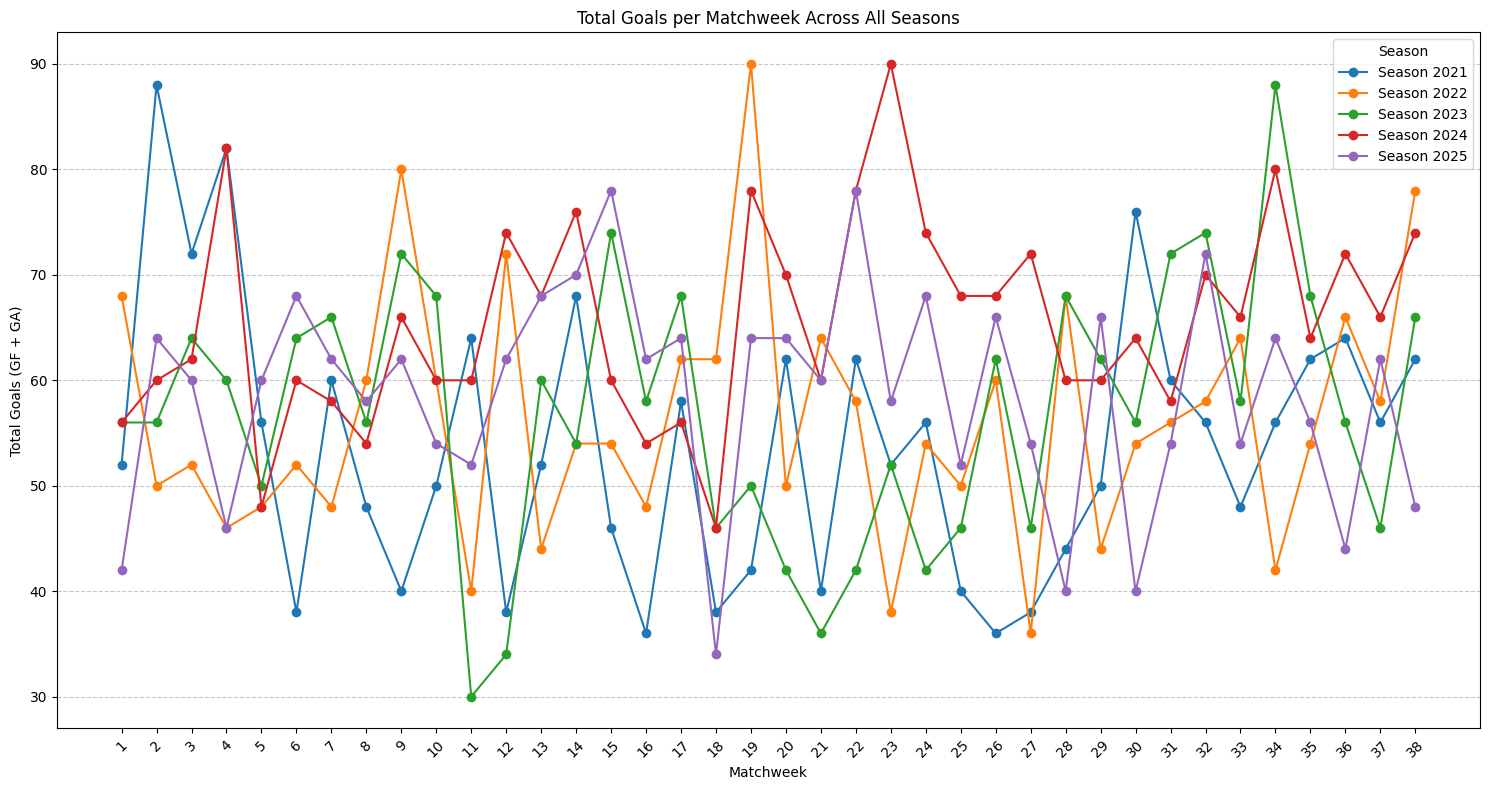

In [5]:
import re

# Extract matchweek number from the 'round' column for the entire DataFrame
df['matchweek_num'] = df['round'].apply(lambda x: int(re.search(r'\d+', x).group()) if pd.notnull(x) and re.search(r'\d+', x) else None)

# Filter out rows where matchweek_num could not be extracted (if any)
df_filtered = df.dropna(subset=['matchweek_num'])

# Get unique seasons
all_seasons = sorted(df_filtered['season'].unique())

plt.figure(figsize=(15, 8))

for season in all_seasons:
    # Filter data for the current season
    df_season = df_filtered[df_filtered['season'] == season]

    # Group by matchweek_num and sum goals (gf + ga)
    matchweek_goals_season = df_season.groupby('matchweek_num')[['gf', 'ga']].sum()
    matchweek_goals_season['total_goals'] = matchweek_goals_season['gf'] + matchweek_goals_season['ga']

    # Sort by matchweek_num to ensure correct plotting order
    matchweek_goals_season = matchweek_goals_season.sort_index()

    # Plot the line for the current season
    plt.plot(matchweek_goals_season.index, matchweek_goals_season['total_goals'], label=f'Season {season}', marker='o', linestyle='-')

plt.xlabel('Matchweek')
plt.ylabel('Total Goals (GF + GA)')
plt.title('Total Goals per Matchweek Across All Seasons')
plt.xticks(sorted(df_filtered['matchweek_num'].unique()), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

In [6]:
df_all_time = []
all_seasons = sorted(df_filtered['season'].unique())

for season in all_seasons:
    df_season = df_filtered[df_filtered['season'] == season]
    matchweek_goals_season = df_season.groupby('matchweek_num')[['gf', 'ga']].sum()
    matchweek_goals_season['total_goals'] = matchweek_goals_season['gf'] + matchweek_goals_season['ga']
    matchweek_goals_season = matchweek_goals_season.sort_index()
    matchweek_goals_season['season'] = str(season).strip()
    df_all_time.append(matchweek_goals_season)

df_arima_ready = pd.concat(df_all_time).reset_index()

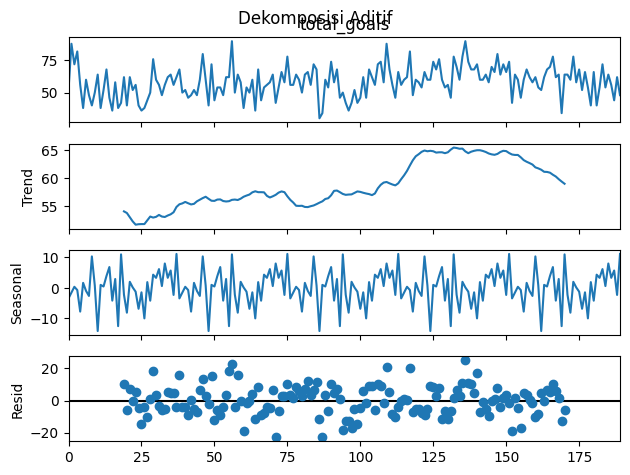

In [7]:
decomp_add = seasonal_decompose(df_arima_ready['total_goals'], model='additive', period=38)
decomp_add.plot()
plt.suptitle("Dekomposisi Aditif")
plt.show()

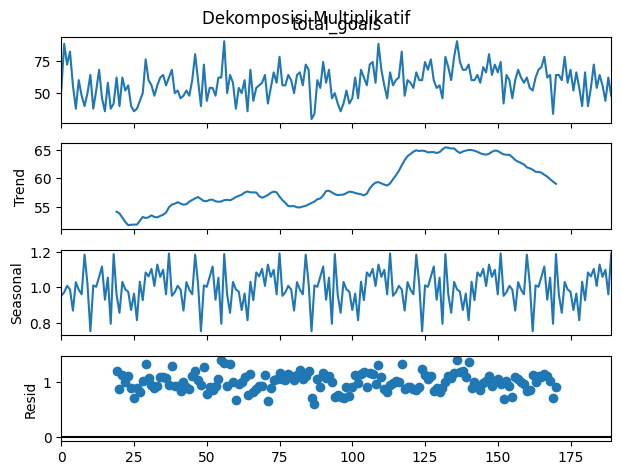

In [8]:
decomp_add = seasonal_decompose(df_arima_ready['total_goals'], model='multiplicative', period=38)
decomp_add.plot()
plt.suptitle("Dekomposisi Multiplikatif")
plt.show()

In [9]:
result = adfuller(df_arima_ready['total_goals'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data stasioner")
else:
    print("Data tidak stasioner")

ADF Statistic: -3.486462517397465
p-value: 0.008341648453028885
Data stasioner


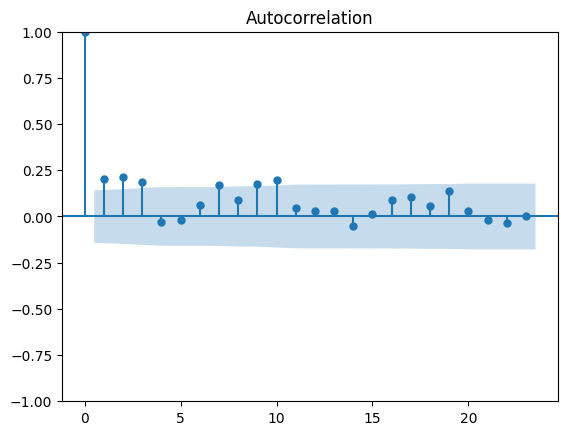

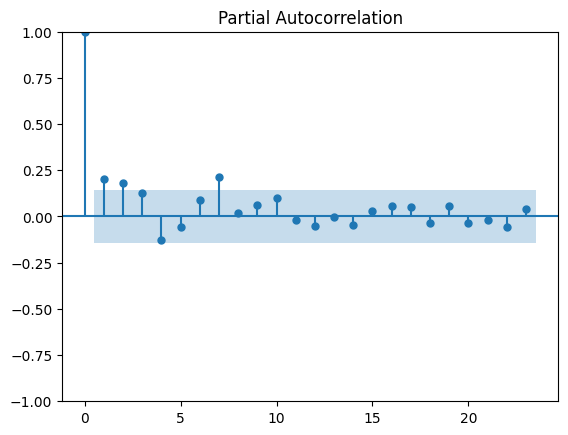

In [10]:
#Plot ACF dan PACF
plot_acf(df_arima_ready['total_goals'])
plt.show()

plot_pacf(df_arima_ready['total_goals'])
plt.show()

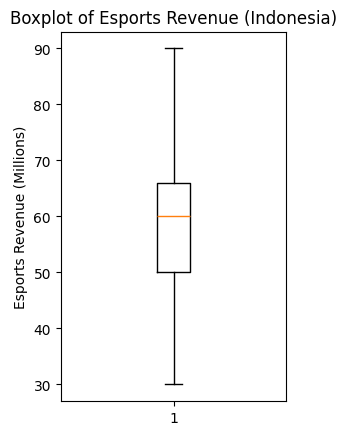

In [11]:
#Visualisasi Boxplot
plt.figure()

plt.subplot(1, 2, 1)
plt.boxplot(df_arima_ready['total_goals'])
plt.title("Boxplot of Esports Revenue (Indonesia)")
plt.ylabel("Esports Revenue (Millions)")

plt.show()

In [12]:
#Deteksi Outlier Metode IQR

series_to_analyze = df_arima_ready['total_goals']

Q1 = series_to_analyze.quantile(0.25)
Q3 = series_to_analyze.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df_arima_ready[(series_to_analyze < lower_bound) | (series_to_analyze > upper_bound)]
outliers_iqr

,matchweek_num,gf,ga,total_goals,season


In [13]:
#Deteksi Outlier Metode Z-Score

series_to_analyze_z = df_arima_ready['total_goals']
z_scores = np.abs(zscore(series_to_analyze_z))

outliers_zscore = df_arima_ready[z_scores > 3]
outliers_zscore

,matchweek_num,gf,ga,total_goals,season


In [14]:
seasons_list = sorted(df_arima_ready['season'].unique())

# Musim terakhir (paling baru) dijadikan data TEST
test_season = seasons_list[-1]

# Musim-musim sebelumnya dijadikan data TRAIN
train_seasons = seasons_list[:-1]

# Lakukan filtering berdasarkan list di atas
df_train = df_arima_ready[df_arima_ready['season'].isin(train_seasons)]
df_test = df_arima_ready[df_arima_ready['season'] == test_season]

print(df_train)
print(df_test)

     matchweek_num  gf  ga  total_goals season
0                1  26  26           52   2021
1                2  44  44           88   2021
2                3  36  36           72   2021
3                4  41  41           82   2021
4                5  28  28           56   2021
..             ...  ..  ..          ...    ...
147             34  40  40           80   2024
148             35  32  32           64   2024
149             36  36  36           72   2024
150             37  33  33           66   2024
151             38  37  37           74   2024

[152 rows x 5 columns]
     matchweek_num  gf  ga  total_goals season
152              1  21  21           42   2025
153              2  32  32           64   2025
154              3  30  30           60   2025
155              4  23  23           46   2025
156              5  30  30           60   2025
157              6  34  34           68   2025
158              7  31  31           62   2025
159              8  29  29          

In [15]:
data = df_arima_ready['total_goals'].values
n_obs = len(data)

train_size = len(df_train)
test_size = len(df_test)


predictions_rolling_sarima = []
true_values_rolling_window = []

# Rolling window forecast
for i in range(train_size, n_obs):
    # Split data into train and test for the current window
    train_data_window = data[0:i]
    test_data_window = data[i:i+1]

    # Fit SARIMA model to the current training window
    model_rolling = SARIMAX(train_data_window, order=(1, 0, 1), seasonal_order=(0, 0, 0, 38))
    model_rolling_fit = model_rolling.fit(disp=False)

    # Make a one-step forecast
    rolling_forecast_single = model_rolling_fit.forecast(steps=1)[0] # Local single forecast variable

    # Store the prediction and the actual value
    predictions_rolling_sarima.append(rolling_forecast_single)
    true_values_rolling_window.append(test_data_window[0])

# Convert lists to numpy arrays
predictions_rolling_sarima = np.array(predictions_rolling_sarima)
true_values_rolling_window = np.array(true_values_rolling_window)

print("First 5 true values (rolling window):")
print(true_values_rolling_window[:5])
print("\nFirst 5 predictions (rolling SARIMA window):")
print(predictions_rolling_sarima[:5])

# You can now evaluate these using metrics like MAPE, RMSE
mape_rolling_sarima = mean_absolute_percentage_error(true_values_rolling_window, predictions_rolling_sarima) * 100
rmse_rolling_sarima = np.sqrt(mean_squared_error(true_values_rolling_window, predictions_rolling_sarima))

print("\n--- HASIL EVALUASI SARIMA (Rolling Window) ---")
print(f"MAPE : {mape_rolling_sarima:.2f}%")
print(f"RMSE : {rmse_rolling_sarima:.2f} Gol")


First 5 true values (rolling window):
[42 64 60 46 60]

First 5 predictions (rolling SARIMA window):
[68.01906383 65.27226747 65.13929467 64.62780515 62.59073915]

--- HASIL EVALUASI SARIMA (Rolling Window) ---
MAPE : 16.50%
RMSE : 11.06 Gol


In [16]:
data = df_arima_ready['total_goals'].values
n_obs = len(data)

train_size = len(df_train)
test_size = len(df_test)

# Initialize lists to store predictions and true values for ROLLING ARIMA
predictions_rolling_arima = []
true_values_rolling_arima = []

# Rolling window forecast
for i in range(train_size, n_obs):
    # Split data into train and test for the current window
    train_data_window = data[0:i]
    test_data_window = data[i:i+1]

    # Fit ARIMA model to the current training window
    model_rolling_arima_current = ARIMA(train_data_window, order=(3, 0, 2))
    model_rolling_fit_arima_current = model_rolling_arima_current.fit()

    # Make a one-step forecast
    rolling_forecast_arima_single = model_rolling_fit_arima_current.forecast(steps=1)[0]

    # Store the prediction and the actual value
    predictions_rolling_arima.append(rolling_forecast_arima_single)
    true_values_rolling_arima.append(test_data_window[0])

# Convert lists to numpy arrays
predictions_rolling_arima = np.array(predictions_rolling_arima)
true_values_rolling_arima = np.array(true_values_rolling_arima)

print("First 5 true values (rolling ARIMA window):")
print(true_values_rolling_arima[:5])
print("\nFirst 5 predictions (rolling ARIMA window):")
print(predictions_rolling_arima[:5])

# You can now evaluate these using metrics like MAPE, RMSE
mape_rolling_arima = mean_absolute_percentage_error(true_values_rolling_arima, predictions_rolling_arima) * 100
rmse_rolling_arima = np.sqrt(mean_squared_error(true_values_rolling_arima, predictions_rolling_arima))

print("\n--- HASIL EVALUASI ARIMA (Rolling Window) ---")
print(f"MAPE : {mape_rolling_arima:.2f}%")
print(f"RMSE : {rmse_rolling_arima:.2f} Gol")


First 5 true values (rolling ARIMA window):
[42 64 60 46 60]

First 5 predictions (rolling ARIMA window):
[63.06149687 58.65925022 57.2697452  54.90538113 58.09522999]

--- HASIL EVALUASI ARIMA (Rolling Window) ---
MAPE : 15.51%
RMSE : 10.04 Gol


In [25]:
# model_arima = ARIMA(df_train['total_goals'].values, order=(3, 0, 2))
model_arima = ARIMA(df_train['total_goals'], order=(3, 0, 2))


arima_fit = model_arima.fit()

print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            total_goals   No. Observations:                  152
Model:                 ARIMA(3, 0, 2)   Log Likelihood                -586.863
Date:                Mon, 20 Jul 2026   AIC                           1187.727
Time:                        02:54:16   BIC                           1208.894
Sample:                             0   HQIC                          1196.325
                                - 152                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.3155      1.628     35.815      0.000      55.124      61.507
ar.L1          0.2994      0.274      1.091      0.275      -0.238       0.837
ar.L2         -0.4579      0.217     -2.109      0.0

In [18]:
model_sarima = SARIMAX(df_train['total_goals'], order=(3, 0, 2), seasonal_order=(3, 0, 2, 38))


sarima_fit = model_sarima.fit()

print(sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                        total_goals   No. Observations:                  152
Model:             SARIMAX(3, 0, 2)x(3, 0, 2, 38)   Log Likelihood                -591.538
Date:                            Mon, 20 Jul 2026   AIC                           1205.076
Time:                                    02:53:45   BIC                           1238.339
Sample:                                         0   HQIC                          1218.588
                                            - 152                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2031      0.339      0.599      0.549      -0.461       0.867
ar.L2          0.8940      0.392   

In [19]:
residual = arima_fit.resid
residual_sarima = sarima_fit.resid


In [20]:
#Uji Ljung-Box
lb_test = acorr_ljungbox(
    residual,
    lags=[10],
    return_df=True
)

print(lb_test)

if lb_test['lb_pvalue'].iloc[0] > 0.05:
    print("Residual tidak mengandung autokorelasi")
else:
    print("Residual masih mengandung autokorelasi")

      lb_stat  lb_pvalue
10  16.414614   0.088363
Residual tidak mengandung autokorelasi


In [21]:
#Uji Heteroskedastisitas
arch_test = het_arch(residual)

print("LM Statistic :", arch_test[0])
print("p-value      :", arch_test[1])

if arch_test[1] < 0.05:
    print("Terdapat efek ARCH")
else:
    print("Tidak terdapat efek ARCH")

LM Statistic : 8.611150152988287
p-value      : 0.5693607440526315
Tidak terdapat efek ARCH


In [27]:
steps = len(df_test)
forecast_result = arima_fit.forecast(steps=steps)
# Removed rolling_result = model_rolling_fit.forecast(steps=steps)
# rolling_result is now predictions_rolling_window from the loop
sarima_forecast_result = sarima_fit.forecast(steps=steps)


In [28]:
y_true = df_test['total_goals'].values
y_pred = forecast_result
sarima_pred = sarima_forecast_result

# Results from rolling window forecasts
rolling_sarima_pred_one_step = predictions_rolling_sarima
rolling_arima_pred_one_step = predictions_rolling_arima

# Menghitung MAPE

mape = mean_absolute_percentage_error(y_true, y_pred) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

mape_sarima = mean_absolute_percentage_error(y_true, sarima_pred) * 100
rmse_sarima = np.sqrt(mean_squared_error(y_true, sarima_pred))

mape_rolling_sarima = mean_absolute_percentage_error(y_true, rolling_sarima_pred_one_step) * 100
rmse_rolling_sarima = np.sqrt(mean_squared_error(y_true, rolling_sarima_pred_one_step))

mape_rolling_arima = mean_absolute_percentage_error(y_true, rolling_arima_pred_one_step) * 100
rmse_rolling_arima = np.sqrt(mean_squared_error(y_true, rolling_arima_pred_one_step))

print("--- HASIL EVALUASI ARIMA (Non-Rolling) ---")
print(f"MAPE : {mape:.2f}%")
print(f"RMSE : {rmse:.2f} Gol")
print("\n--- HASIL EVALUASI SARIMA (Non-Rolling) ---")
print(f"MAPE : {mape_sarima:.2f}%")
print(f"RMSE : {rmse_sarima:.2f} Gol")
print("\n--- HASIL EVALUASI ROLLING SARIMA (One-Step Ahead) ---")
print(f"MAPE : {mape_rolling_sarima:.2f}%")
print(f"RMSE : {rmse_rolling_sarima:.2f} Gol")
print("\n--- HASIL EVALUASI ROLLING ARIMA (One-Step Ahead) ---")
print(f"MAPE : {mape_rolling_arima:.2f}%")
print(f"RMSE : {rmse_rolling_arima:.2f} Gol")


--- HASIL EVALUASI ARIMA (Non-Rolling) ---
MAPE : 15.34%
RMSE : 10.30 Gol

--- HASIL EVALUASI SARIMA (Non-Rolling) ---
MAPE : 20.60%
RMSE : 13.40 Gol

--- HASIL EVALUASI ROLLING SARIMA (One-Step Ahead) ---
MAPE : 16.50%
RMSE : 11.06 Gol

--- HASIL EVALUASI ROLLING ARIMA (One-Step Ahead) ---
MAPE : 15.51%
RMSE : 10.04 Gol


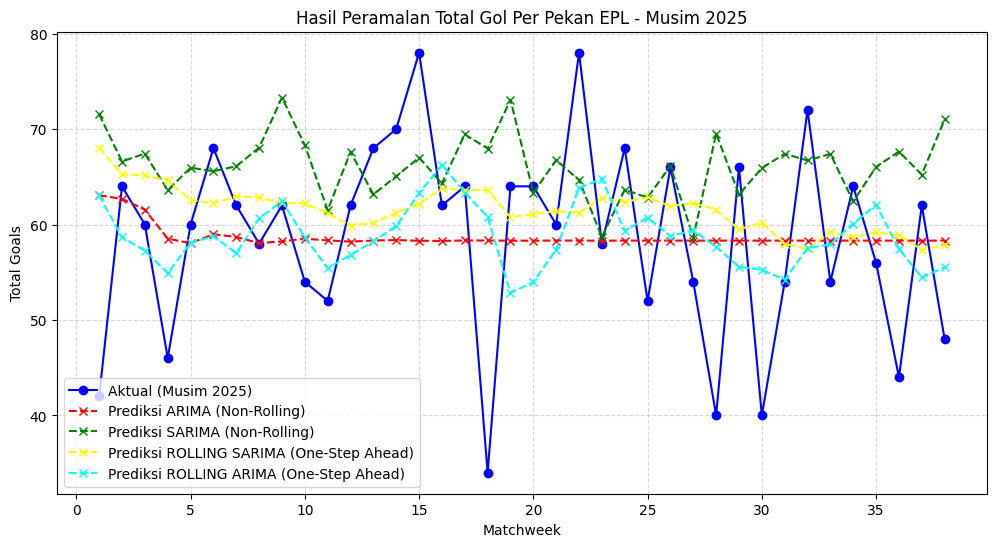

In [29]:
plt.figure(figsize=(12, 6))
plt.plot(df_test['matchweek_num'], y_true, label='Aktual (Musim 2025)', marker='o', color='blue')
plt.plot(df_test['matchweek_num'], y_pred, label='Prediksi ARIMA (Non-Rolling)', marker='x', linestyle='--', color='red')
plt.plot(df_test['matchweek_num'], sarima_pred, label='Prediksi SARIMA (Non-Rolling)', marker='x', linestyle='--', color='green')
plt.plot(df_test['matchweek_num'], predictions_rolling_sarima, label='Prediksi ROLLING SARIMA (One-Step Ahead)', marker='x', linestyle='--', color='yellow')
plt.plot(df_test['matchweek_num'], predictions_rolling_arima, label='Prediksi ROLLING ARIMA (One-Step Ahead)', marker='x', linestyle='--', color='cyan')
plt.title('Hasil Peramalan Total Gol Per Pekan EPL - Musim 2025')
plt.xlabel('Matchweek')
plt.ylabel('Total Goals')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
